In [2]:
import string
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from pubmed_loader import PubMedQAData

In [3]:
LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}
LABEL_NAMES_INV = {0: "yes", 1: "no", 2: "maybe"}
RANDOM_SEED = 11

# BioWordVec pretrained vectors can be downloaded from:
# https://github.com/ncats/BioSentVec
# File: BioWordVec_PubMed_MIMICIII_d200.vec.bin (word2vec bin format)
MODEL_PATH = r"E:\0000NLP_Models\BioWordVec_PubMed_MIMICIII_d200.vec.bin"

## 1. Preprocessing

In [4]:
def clean_text_plus(text):
    text = text.lower()
    keep = {"-"}
    puncts = "".join(c for c in string.punctuation if c not in keep)
    text = text.translate(str.maketrans("", "", puncts))
    tokens = [t for t in text.split() if not re.fullmatch(r"[\d.]+", t)]
    return tokens


def build_input(sample):
    question = sample["QUESTION"]
    context  = " ".join(sample["CONTEXTS"])
    return question + " " + context


def preprocess_biowordvec(dataset, clean_fn=clean_text_plus):
    tokens_list, labels = [], []
    for pmid, sample in dataset.items():
        tokens = clean_fn(build_input(sample))
        tokens_list.append(tokens)
        labels.append(LABEL_NAMES[sample["final_decision"]])
    return tokens_list, labels

In [5]:
data = PubMedQAData("data")

train_tokens, train_labels = preprocess_biowordvec(data.train_set)
dev_tokens,   dev_labels   = preprocess_biowordvec(data.dev_set)

# Test set: labels from test_ground_truth
test_tokens, _ = preprocess_biowordvec(data.test_set)
test_pmids     = list(data.test_set.keys())
test_labels    = [LABEL_NAMES[data.test_ground_truth[pmid]] for pmid in test_pmids]

print(f"train: {len(train_tokens)} samples")
print(f"dev:   {len(dev_tokens)}   samples")
print(f"test:  {len(test_tokens)}  samples")

train: 450 samples
dev:   50   samples
test:  500  samples


In [6]:
print("Train:", np.bincount(train_labels))
print("Dev:  ", np.bincount(dev_labels))
print("Test: ", np.bincount(test_labels))

Train: [249 152  49]
Dev:   [27 17  6]
Test:  [276 169  55]


In [7]:
# Combine train + dev for cross-validation (500 samples total)
combined_tokens = train_tokens + dev_tokens
combined_labels = train_labels + dev_labels

## 2. Load BioWordVec & Vectorize

In [8]:
def vectorize(tokens_list, model, dim=200):
    """
    Convert a list of token lists into a matrix of sentence vectors.
    Each sentence vector is the mean of its token vectors (mean pooling).
    Tokens not found in the model vocabulary are skipped.
    If no tokens are found, a zero vector is used.
    """
    vectors = []
    for tokens in tokens_list:
        token_vecs = [model[t] for t in tokens if t in model]
        if token_vecs:
            vectors.append(np.mean(token_vecs, axis=0))
        else:
            vectors.append(np.zeros(dim))
    return np.array(vectors)

In [9]:
print("Loading BioWordVec model...")
bwv_model = KeyedVectors.load_word2vec_format(MODEL_PATH, binary=True)
print(f"Model loaded. Vocabulary size: {len(bwv_model)}")

Loading BioWordVec model...
Model loaded. Vocabulary size: 16545452


In [10]:
X_train = vectorize(combined_tokens, bwv_model)
X_test  = vectorize(test_tokens,     bwv_model)
y_train = np.array(combined_labels)
y_test  = np.array(test_labels)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (500, 200)
X_test shape:  (500, 200)


## 3. Train SVM with Grid Search + 5-fold CV

In [11]:
param_grid = {
    "C":      [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

grid_search = GridSearchCV(
    SVC(class_weight="balanced"),
    param_grid,
    cv=cv,
    scoring="f1_macro",
    verbose=1,
    n_jobs=4
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_weight='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [12]:
import pandas as pd

def print_grid_search_summary(grid_search, top_n=5):
    results_df = pd.DataFrame(grid_search.cv_results_)
    cols = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    summary = results_df[cols].sort_values(by='rank_test_score')
    print(f"Top {top_n} Hyperparameter Combinations")
    print(summary.head(top_n).to_string(index=False))

print_grid_search_summary(grid_search)

Top 5 Hyperparameter Combinations
                        params  mean_test_score  std_test_score  rank_test_score
    {'C': 10, 'kernel': 'rbf'}         0.366062        0.065144                1
     {'C': 1, 'kernel': 'rbf'}         0.358777        0.032066                2
 {'C': 10, 'kernel': 'linear'}         0.349680        0.030746                3
  {'C': 1, 'kernel': 'linear'}         0.347618        0.046859                4
{'C': 0.1, 'kernel': 'linear'}         0.273236        0.021364                5


In [13]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")

best_svm = grid_search.best_estimator_

Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best CV Score (F1): 0.3661


## 4. Evaluate

In [14]:
def evaluate(y_pred, y_true, split_name):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    print(f"\n── {split_name} ──")
    print(f"Accuracy: {acc:.4f}  Macro-F1: {f1:.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=["yes", "no", "maybe"]
    ))


def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["yes", "no", "maybe"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix – BioWordVec + SVM")
    plt.show()

In [15]:
y_pred = best_svm.predict(X_test)
evaluate(y_pred, y_test, "Test_set")


── Test_set ──
Accuracy: 0.4500  Macro-F1: 0.3911
              precision    recall  f1-score   support

         yes       0.62      0.49      0.55       276
          no       0.44      0.43      0.43       169
       maybe       0.14      0.29      0.19        55

    accuracy                           0.45       500
   macro avg       0.40      0.41      0.39       500
weighted avg       0.51      0.45      0.47       500



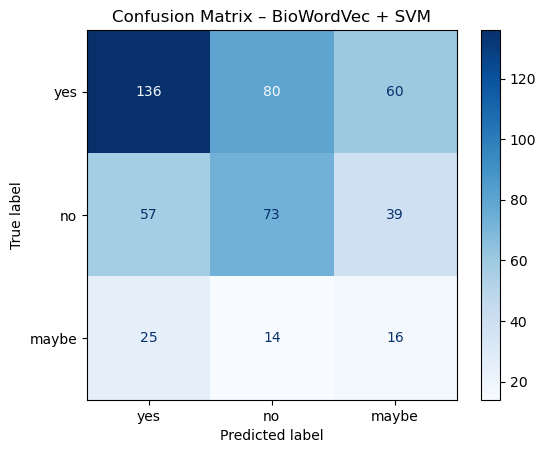

In [16]:
plot_confusion_matrix(y_test, y_pred)

## 5. Error Analysis

In [17]:
print("\nError samples (top 5)")
test_items = list(data.test_set.items())
errors = [
    (pmid, sample, y_test[i], y_pred[i])
    for i, (pmid, sample) in enumerate(test_items)
    if y_test[i] != y_pred[i]
]

for pmid, sample, true, pred in errors[:5]:
    print(f"\nPMID: {pmid}")
    print(f"Question : {sample['QUESTION']}")
    print(f"True     : {LABEL_NAMES_INV[true]}")
    print(f"Predicted: {LABEL_NAMES_INV[pred]}")


Error samples (top 5)

PMID: 18537964
Question : Does a physician's specialty influence the recording of medication history in patients' case notes?
True     : yes
Predicted: no

PMID: 24481006
Question : Should cavitation in proximal surfaces be reported in cone beam computed tomography examination?
True     : yes
Predicted: no

PMID: 22680064
Question : Can third trimester ultrasound predict the presentation of the first twin at delivery?
True     : yes
Predicted: no

PMID: 20629769
Question : Is primary angioplasty an acceptable alternative to thrombolysis?
True     : yes
Predicted: maybe

PMID: 22902073
Question : Estimated fetal weight by ultrasound: a modifiable risk factor for cesarean delivery?
True     : yes
Predicted: no
